In [1]:
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt

In [3]:
def make_cos_phi_operator(N):
    """
    Constructs the cos(φ) operator in the charge basis for a given cutoff N.
    
    Parameters:
    N (int): The cutoff for the charge basis, resulting in a (2N+1)x(2N+1) matrix.
    
    Returns:
    Qobj: The cos(φ) operator as a QuTiP quantum object.
    """
    dim = 2 * N + 1
    cos_phi_np = np.zeros((dim, dim), dtype=complex)

    for n in range(-N, N + 1): # loops from -N to N inclusive
        if n + 1 <= N:
            cos_phi_np[n + N, n + 1 + N] = 0.5
        if n - 1 >= -N:
            cos_phi_np[n + N, n - 1 + N] = 0.5
    
    return qt.Qobj(cos_phi_np, dims=[[dim], [dim]])

def make_Hamiltonian(eta, ng, N):
    """
    Constructs the Hamiltonian for a Cooper pair box in the charge basis.
    
    Parameters:
    eta (float): sqrt(8 * Ej / Ec)
    ng (float): Offset charge.
    N (int): Cutoff for the charge basis.
    
    Returns:
    Qobj: The Hamiltonian as a QuTiP quantum object.
    """
    dim = 2 * N + 1
    charge = charge_op(N)
    I = qt.qeye(dim)
    cos_phi_op = make_cos_phi_operator(N)
    
    H = (eta / 2) * (charge - ng * I)**2 - (1 / eta) * cos_phi_op
    return H

def charge_op(N):
    dim = 2 * N + 1
    return qt.Qobj(np.diag(np.arange(-N, N + 1)), dims=[[dim], [dim]])

# C

In [ ]:
N = 100 
n_g_values = np.linspace(-2, 2, 400)
Ej_over_Ec_values = [0.1, 1, 10, 100]
num_evals = 4

energies = np.zeros((len(Ej_over_Ec_values), len(n_g_values), num_evals))

for i, Ej_over_Ec in enumerate(Ej_over_Ec_values):
    for j, ng in enumerate(n_g_values):
        eta = np.sqrt(8 / Ej_over_Ec)  # Calculate eta from the given ratio of Ej/Ec
        evals = make_Hamiltonian(eta, ng, N).eigenenergies() # get eigenvalues of the Hamiltonian
        energies[i, j, :] = evals[:num_evals] # Store energy values we want to plot

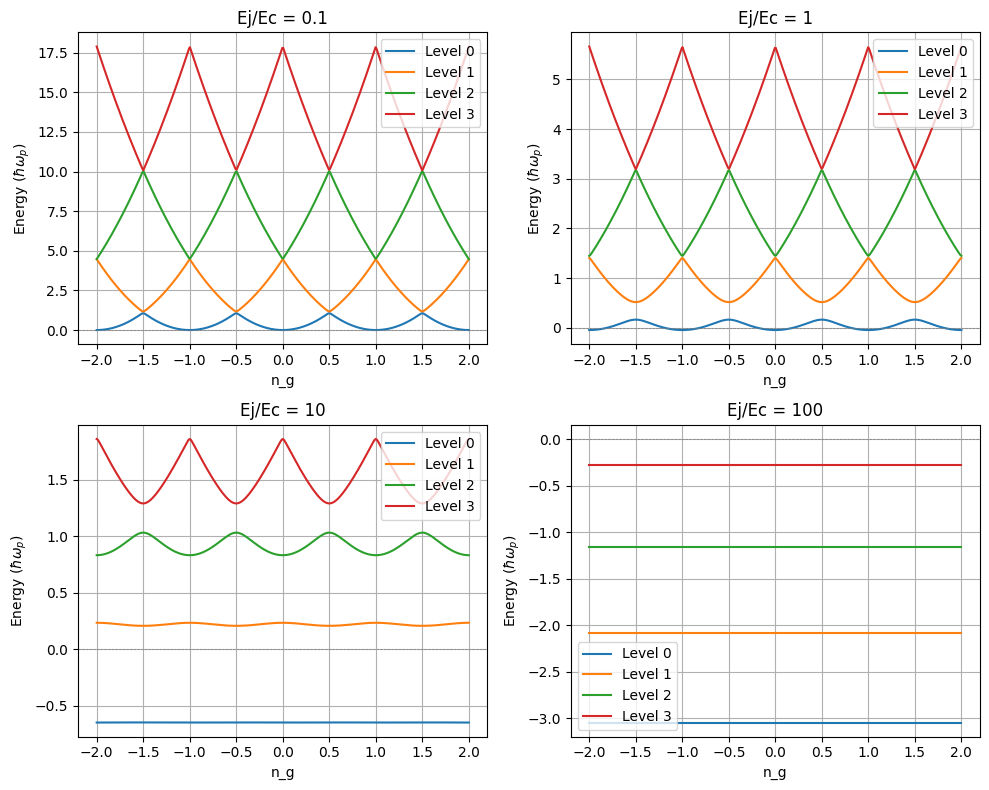

In [14]:
# Plotting the energy levels
plt.figure(figsize=(10, 8))
for i, Ej_over_Ec in enumerate(Ej_over_Ec_values):
    plt.subplot(2, 2, i + 1) # Create a 2x2 grid of subplots
    for n in range(num_evals):
        plt.plot(n_g_values, energies[i, :, n], label=f'Level {n}')
    plt.title(f'Ej/Ec = {Ej_over_Ec}')
    plt.xlabel('n_g')
    plt.ylabel(r'Energy ($\hbar \omega_p$)')
    plt.axhline(0, color='gray', linestyle='--', linewidth=0.5)
    plt.legend()
    plt.grid()
plt.tight_layout()
plt.show()

# d

In [36]:
N = 100 
n_g = 0.5
Ej_over_Ec_values = [0.1, 1, 10, 100]
num_evec = 2 

evecs = np.zeros((len(Ej_over_Ec_values), num_evec, 2 * N + 1), dtype=complex)

for i, Ej_over_Ec in enumerate(Ej_over_Ec_values):
    eta = np.sqrt(8 / Ej_over_Ec)  # Calculate eta from the given ratio of Ej/Ec
    H = make_Hamiltonian(eta, n_g, N)
    evals, evecs_i = H.eigenstates()
    for n in range(num_evec):
        evecs[i, n, :] = evecs_i[n].full().flatten() # Store the eigenvector components for plotting

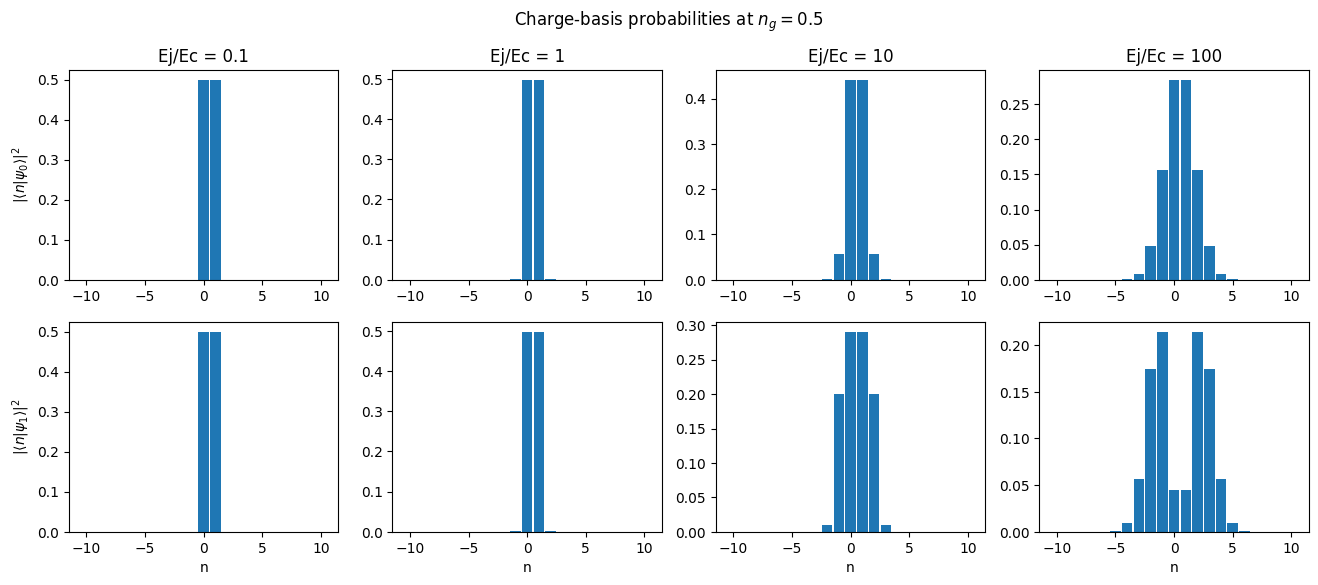

In [ ]:
charges = np.arange(-N, N + 1)
probs = np.abs(evecs)**2
n_window = 10 # charge plotting window around n=0
mask = (charges >= -n_window) & (charges <= n_window) # numpy array of booleans to select charges within the window

fig, axes = plt.subplots(
    num_evec,
    len(Ej_over_Ec_values),
    figsize=(4 * len(Ej_over_Ec_values), 3 * num_evec) # scale figure size based on number of subplots
)

for i, Ej_over_Ec in enumerate(Ej_over_Ec_values):
    for n in range(num_evec):
        ax = axes[n, i] # select the appropriate subplot for state n and ratio i
        ax.bar(charges[mask], probs[i, n, mask], width=0.9)

        if n == 0:
            ax.set_title(f'Ej/Ec = {Ej_over_Ec}') # title only for the top row
        if i == 0:
            ax.set_ylabel(rf"$|\langle n | \psi_{n}\rangle|^2$") # y-label only for the first column
        if n == num_evec - 1:
            ax.set_xlabel('n')

fig.suptitle(rf'Charge-basis probabilities at $n_g={n_g}$')
plt.show()

# e

In [41]:
N = 100 
Ej_over_Ec_values = np.linspace(0.0001, 100, 1000) # Use a dense set of Ej/Ec values
num_evals = 4 

dispersion = np.zeros((len(Ej_over_Ec_values), num_evals), dtype=float)

for i, Ej_over_Ec in enumerate(Ej_over_Ec_values):
    eta = np.sqrt(8 / Ej_over_Ec)  # Calculate eta from the given ratio of Ej/Ec
    H = make_Hamiltonian(eta, 0, N)
    evals_ng0 = H.eigenenergies()

    H = make_Hamiltonian(eta, 0.5, N)
    evals_ng05 = H.eigenenergies()

    dispersion[i, :] = np.abs(evals_ng05[:num_evals] - evals_ng0[:num_evals]) # Store the energy difference for plotting

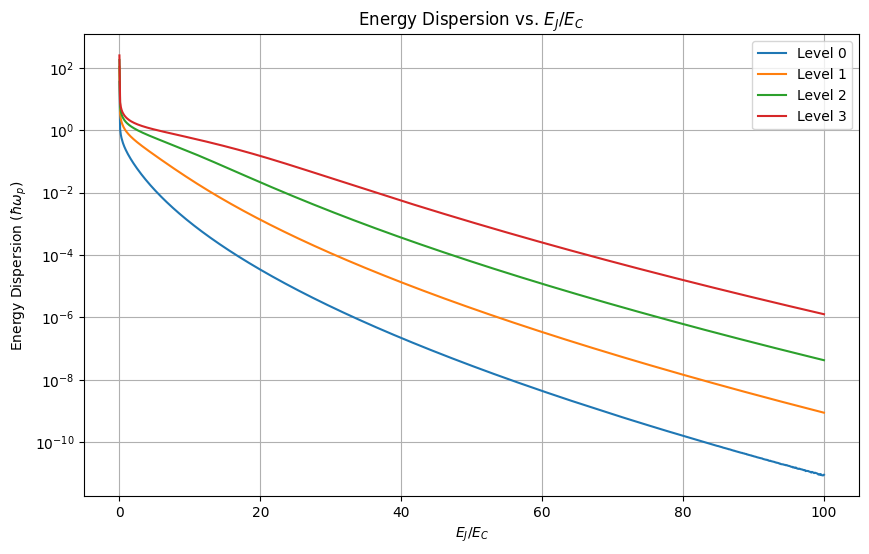

In [43]:
plt.figure(figsize=(10, 6))
for n in range(num_evals):
    plt.plot(Ej_over_Ec_values, dispersion[:, n], label=f'Level {n}')
plt.xlabel(r'$E_J/E_C$')
plt.ylabel(r'Energy Dispersion ($\hbar \omega_p$)')
plt.yscale('log') # Use logarithmic scale for better visibility of small energy differences
plt.title(r'Energy Dispersion vs. $E_J/E_C$')
plt.legend()
plt.grid()
plt.show()

# f

In [23]:
N = 100 
Ej_over_Ec_values = np.linspace(0.0001, 100, 1000) # Use a dense set of Ej/Ec values
n_g = 0.5
num_evals = 3

anharmonicity = np.zeros(len(Ej_over_Ec_values), dtype=float)

for i, Ej_over_Ec in enumerate(Ej_over_Ec_values):
    eta = np.sqrt(8 / Ej_over_Ec)  # Calculate eta from the given ratio of Ej/Ec
    H = make_Hamiltonian(eta, n_g, N)
    evals_ng = H.eigenenergies()
    anharmonicity[i] = (evals_ng[2] - 2*evals_ng[1] + evals_ng[0]) / (evals_ng[1] - evals_ng[0])  # Calculate anharmonicity as the difference between the second and first excited states divided by the first excited state energy difference

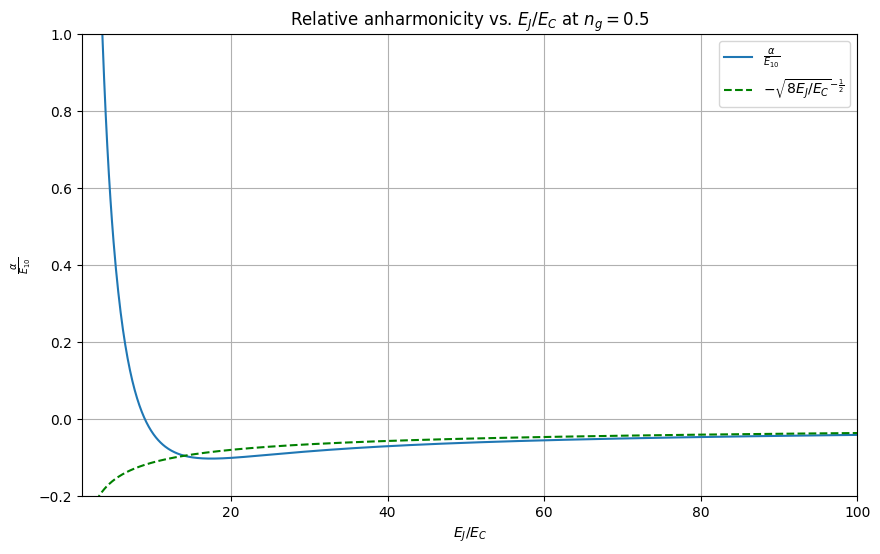

In [52]:
def fit_high_Ej_over_Ec(Ej_over_Ec):
    return - np.sqrt(8 * Ej_over_Ec) ** (-1) # Fit function for high Ej/Ec limit

plt.figure(figsize=(10, 6))
plt.plot(Ej_over_Ec_values, anharmonicity, label=r'$\frac{\alpha}{E_{10}}$')
plt.plot(Ej_over_Ec_values, fit_high_Ej_over_Ec(Ej_over_Ec_values), 'g--', label=r'$-\sqrt{8 E_J/E_C}^{-\frac{1}{2}}$')
plt.xlabel(r'$E_J/E_C$')
plt.ylabel(r'$\frac{\alpha}{E_{10}}$')
plt.title(r'Relative anharmonicity vs. $E_J/E_C$ at $n_g=0.5$')
plt.grid()
plt.xlim(1, 100)
plt.ylim(-0.2, 1)
plt.legend()
plt.show()

In [53]:
N = 100 
Ej_over_Ec_values = np.linspace(0.0001, 1, 1000) # Use a dense set of Ej/Ec values
n_g = 0.5
num_evals = 3

anharmonicity = np.zeros(len(Ej_over_Ec_values), dtype=float)

for i, Ej_over_Ec in enumerate(Ej_over_Ec_values):
    eta = np.sqrt(8 / Ej_over_Ec)  # Calculate eta from the given ratio of Ej/Ec
    H = make_Hamiltonian(eta, n_g, N)
    evals_ng = H.eigenenergies()
    anharmonicity[i] = (evals_ng[2] - 2*evals_ng[1] + evals_ng[0]) / (evals_ng[1] - evals_ng[0])  # Calculate anharmonicity as the difference between the second and first excited states divided by the first excited state energy difference

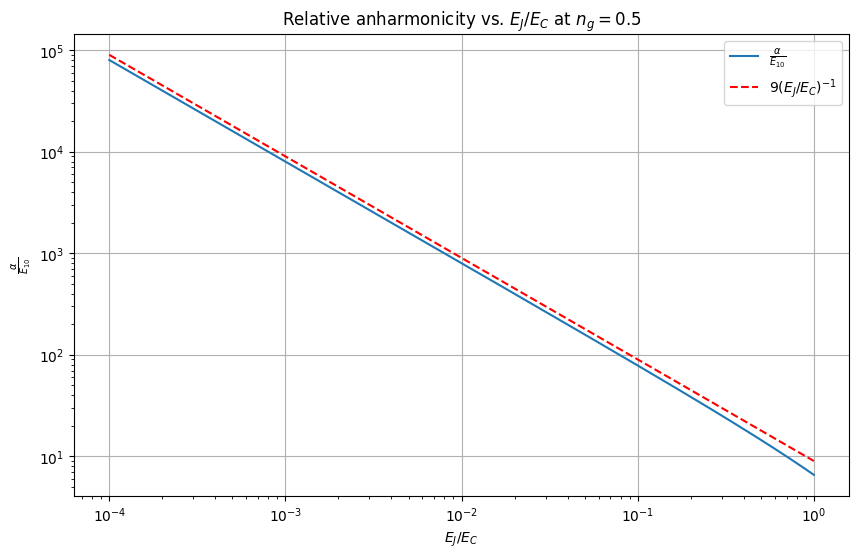

In [60]:
def fit_low_Ej_over_Ec(Ej_over_Ec):
    return 9/ Ej_over_Ec # Fit function for low Ej/Ec limit

plt.figure(figsize=(10, 6))
plt.plot(Ej_over_Ec_values, anharmonicity, label=r'$\frac{\alpha}{E_{10}}$')
plt.plot(Ej_over_Ec_values, fit_low_Ej_over_Ec(Ej_over_Ec_values), 'r--', label=r'$9(E_J/E_C)^{-1}$')
plt.xlabel(r'$E_J/E_C$')
plt.ylabel(r'$\frac{\alpha}{E_{10}}$')
plt.yscale('log') # Use logarithmic scale for better visibility of small anharmonicity values
plt.xscale('log') # Use logarithmic scale for better visibility of small Ej/Ec values
plt.title(r'Relative anharmonicity vs. $E_J/E_C$ at $n_g=0.5$')
plt.grid()
plt.legend()
plt.show()

In [19]:
N = 100 
n_g_values = np.linspace(0, 1, 100)
Ej_over_Ec_values = [0.1, 1, 10, 50, 100]
num_elements = 3

charge_matrix_elements = np.zeros((len(Ej_over_Ec_values), len(n_g_values), num_elements))

for i, Ej_over_Ec in enumerate(Ej_over_Ec_values):
    for j, ng in enumerate(n_g_values):
        eta = np.sqrt(8 / Ej_over_Ec)  # Calculate eta from the given ratio of Ej/Ec
        evals, evecs = make_Hamiltonian(eta, ng, N).eigenstates() # get eigenvalues and eigenvectors of the Hamiltonian
        charge_matrix_elements[i, j, 0] = np.abs(evecs[1].dag() * charge_op(N) * evecs[0])  # compute magnitude of matrix elements of charge operator in the eigenbasis
        charge_matrix_elements[i, j, 1] = np.abs(evecs[2].dag() * charge_op(N) * evecs[0])  # compute magnitude of matrix elements of charge operator in the eigenbasis
        charge_matrix_elements[i, j, 2] = np.abs(evecs[3].dag() * charge_op(N) * evecs[0]) # compute magnitude of matrix elements of charge operator in the eigenbasis

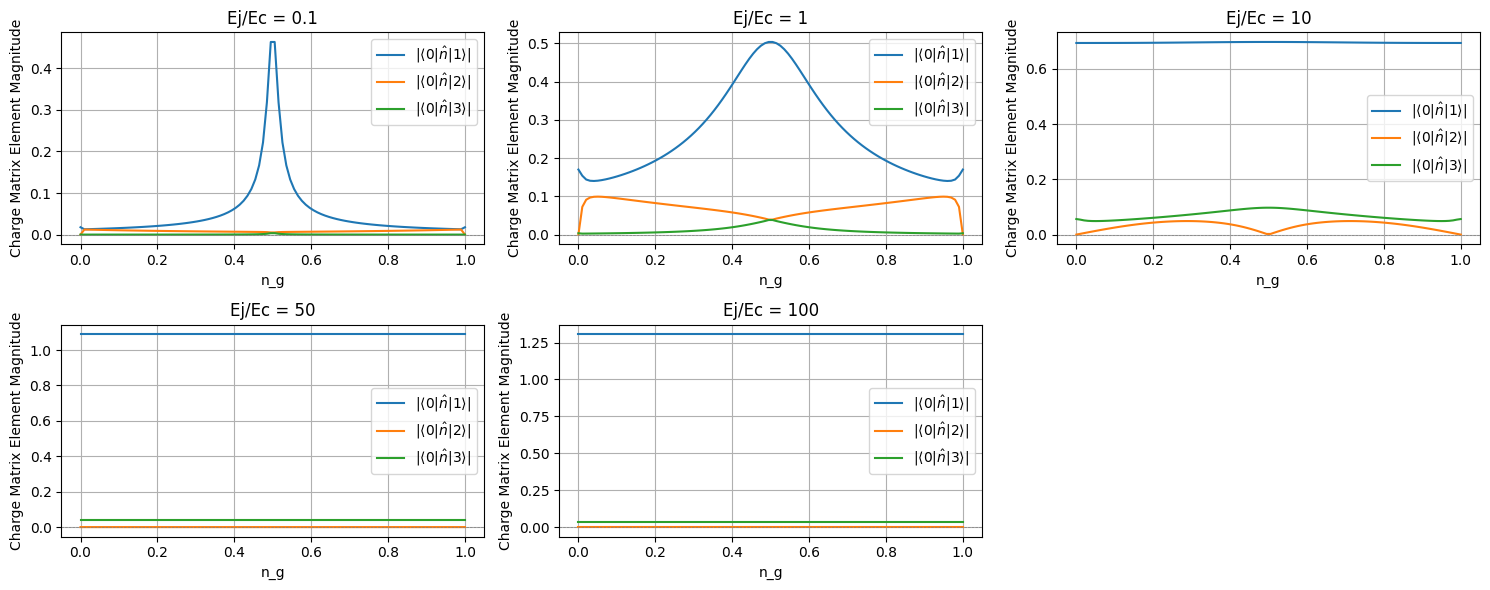

In [20]:
# Plotting the energy levels
plt.figure(figsize=(15, 6))
for i, Ej_over_Ec in enumerate(Ej_over_Ec_values):
    plt.subplot(2, 3, i + 1) # Create a 2x3 grid of subplots
    for n in range(num_elements):
        plt.plot(n_g_values, charge_matrix_elements[i, :, n], label=rf'$|\langle 0|\hat{{n}}|{n + 1}\rangle|$')
    plt.title(f'Ej/Ec = {Ej_over_Ec}')
    plt.xlabel('n_g')
    plt.ylabel(r'Charge Matrix Element Magnitude')
    plt.axhline(0, color='gray', linestyle='--', linewidth=0.5)
    plt.legend()
    plt.grid()
plt.tight_layout()
plt.show()

In [1]:
!jupyter nbconvert "P2.ipynb" --to html
!open "P2.html"

[NbConvertApp] Converting notebook P2.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 6 image(s).
[NbConvertApp] Writing 826311 bytes to P2.html
